# T02 · AtomicDipolesMACE — learning vector properties

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Neutrino155/MACE_tutorials/blob/main/MACE_extensions/T02-AtomicDipolesMACE.ipynb)

**Lennard-Jones Centre · University of Cambridge · Atomic-Scale Modelling**

Trace a symmetry-correct dipole readout, inspect its training data and test how the predicted vector changes when a water molecule rotates.

**Route:** architecture in [T00](T00-Extending-MACE.ipynb); training foundations in [Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb) and [Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb); optional theory in [MACE Theory](../MACE_advanced/T03-MACE-Theory.ipynb).

## Setup

Run the setup and import cells in order. Local Jupyter needs a compatible MACE-Field `origin/develop` checkout (`MACEFIELD_ROOT`); Colab fetches the source and required dependencies. See the [extension guide](README.md) for source revisions and data notes.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
_original_showwarning = warnings.showwarning

def _quiet_user_and_deprecation_warnings(message, category, filename, lineno,
                                         file=None, line=None):
    if issubclass(category, (UserWarning, DeprecationWarning)):
        return
    _original_showwarning(message, category, filename, lineno, file=file, line=line)

warnings.showwarning = _quiet_user_and_deprecation_warnings

import importlib.util
import subprocess
import sys
from pathlib import Path

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except (ImportError, ValueError):
    IN_COLAB = False
if IN_COLAB:
    TUTORIAL_ROOT = Path("/content/MACE_tutorials")
    if not (TUTORIAL_ROOT / "MACE_extensions").is_dir():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main",
             "https://github.com/Neutrino155/MACE_tutorials.git", str(TUTORIAL_ROOT)],
            check=True,
        )
else:
    TUTORIAL_ROOT = next(
        (root for root in (Path.cwd(), *Path.cwd().parents)
         if (root / "MACE_extensions").is_dir()),
        None,
    )
    if TUTORIAL_ROOT is None:
        raise FileNotFoundError("Open this notebook from the MACE_tutorials repository.")

sys.path.insert(0, str(TUTORIAL_ROOT))
from MACE_extensions.scripts.notebook_setup import setup

SETUP = setup(feature="base")
ASSET_ROOT = Path(SETUP["asset_root"])
REPO = Path(SETUP["source_root"])


MACE-Field source: /home/brad/repositories/mace-field-develop · Colab: False
CUDA NVRTC libraries prepared from: /home/brad/miniconda3/envs/mace-field/lib/python3.14/site-packages/nvidia/cu13/lib


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import inspect
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from ase import Atoms
from ase.io import read
from IPython.display import display
from mace.calculators import MACECalculator
from mace.modules.extensions import MACEField, MACELES
from mace.modules.models import AtomicDipolesMACE

from MACE_extensions.scripts.notebook_tools import read_source, show_source_hits
import importlib

structure_viewer = importlib.import_module("MACE_extensions.scripts.structure_viewer")
importlib.reload(structure_viewer)
animate_structures = structure_viewer.animate_structures
show_structure = structure_viewer.show_structure
show_structure_gallery = structure_viewer.show_structure_gallery

DEVICE = os.environ.get(
    "MACE_TUTORIAL_DEVICE",
    "cuda" if torch.cuda.is_available() else "cpu",
)
MODEL_DTYPE = "float64"
MODEL_PATHS = {
    "dipole": Path(SETUP["dipoles_model"]),
    "magnetic": Path(SETUP["magnetic_model"]),
    "les": Path(SETUP["les_model"]),
    "short_range": Path(SETUP["les_local_control"]),
}
if "macefield_model" in SETUP:
    MODEL_PATHS["field"] = Path(SETUP["macefield_model"])

def require_model(name):
    path = Path(MODEL_PATHS[name])
    if not path.is_file():
        raise FileNotFoundError(f"Model file not found: {path}")
    return path

print(f"Source: {REPO} · {'Colab' if IN_COLAB else 'local Jupyter'} · {DEVICE}")

# Reapply after imports because some scientific packages reset warning filters.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.showwarning = _quiet_user_and_deprecation_warnings


Source: /home/brad/repositories/mace-field-develop · local Jupyter · cpu


### Inspect example structures

Choose a teaching set from the menu, then rotate and zoom to inspect its geometry and available overlays.

In [3]:
DATA_CHOICES = {
    "BaTiO₃ soft-mode training data": "macefield_batio3_toy_train.extxyz",
    "Water dipole training data": "atomicdipoles_water_train.extxyz",
    "Fe₂ magnetic training data": "magnetic_fe2_train.extxyz",
    "Water dimer LES training data": "maceles_water_dimer_train.extxyz",
}

example_structures = {
    name: read(ASSET_ROOT / "data" / filename, index=0)
    for name, filename in DATA_CHOICES.items()
}
display(show_structure_gallery(
    example_structures,
    title="Inspect the teaching structures",
    default_choice='Water dipole training data',
))


<IPython.core.display.Javascript object>

## Extension 2 — AtomicDipolesMACE: read out a vector property

### 2.1 Architecture change

A molecular dipole is a polar vector. AtomicDipolesMACE keeps the equivariant MACE trunk and adds an $l=1$ readout to node features. It sums atomic contributions and an optional fixed-charge baseline,

$$\boldsymbol\mu=\sum_i\boldsymbol\mu_i+\sum_iq_i\mathbf r_i.$$

This is a direct-property model, not an energy derivative: it does not provide conservative forces by itself, and atomic contributions are not unique observables.

#### Readout in the architecture

Each interaction–product stage contributes an atomic vector; contributions are summed over layers and atoms. The inherited energy path is shown for comparison: this class returns dipole outputs, not energy or forces.

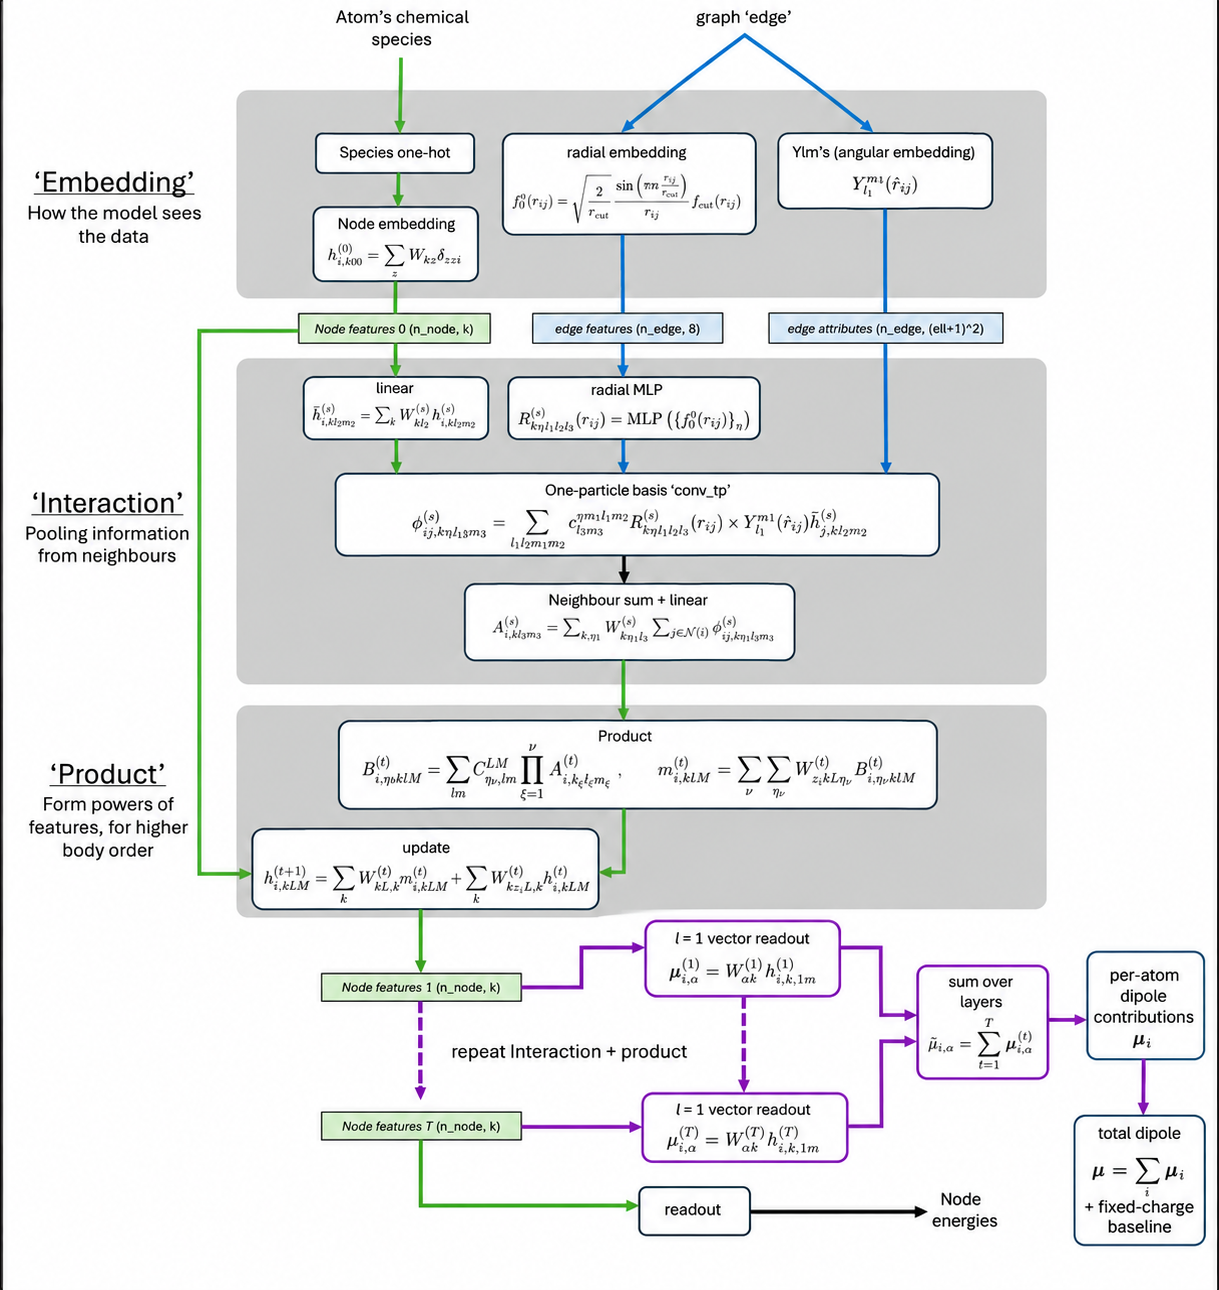

### 2.2 Symmetry, units and boundary conditions

Check these conventions before fitting or rotating dipole labels.

<details>
<summary><b>Background theory: molecular dipole conventions</b></summary>

- **Rotation:** rotate a molecule and its reference dipole by the same Q. Compare the full vector, not only its magnitude.
- **Translation:** a neutral molecule's total dipole is origin independent. For a non-neutral object, it is origin dependent; state the chosen origin.
- **Parity:** an electric dipole is polar. Under inversion it changes sign.
- **Charge baseline:** fixed charges contribute Σqᵢrᵢ. Keep charge and coordinate units consistent, and do not interpret learned μᵢ as QM partial charges.
- **Periodic systems:** polarization has a different definition and branch ambiguity in periodic solids. AtomicDipolesMACE is not a replacement for MACEField's periodic polarization path.
- **Calculator interface:** this checkout's ASE interface calls this trained model type <code>DipoleMACE</code>; the training selector is <code>AtomicDipolesMACE</code>. The calculator returns the dipole in the units expected by the checkpoint/training path; verify the dataset convention.
</details>

### 2.3 Follow the implementation

Trace the required irreps, readout placement, atom-to-molecule reduction and unsupported energy outputs in the source.

In [4]:
show_source_hits(
    AtomicDipolesMACE.__init__,
    needles=("LinearDipoleReadoutBlock", "NonLinearDipoleReadoutBlock", "hidden_irreps_out"),
    context=7,
)

show_source_hits(
    AtomicDipolesMACE.forward,
    needles=("readout(node_feats)", "atomic_dipoles", "compute_fixed_charge_dipole", '"dipole"'),
    context=6,
)

639 640 641 642 643 644 645 646 647 648 649 650 651 652 653 654 655 656 657 658 659 660 661 662 663 664 665 666 667 668 669 670 671 672 673 674 675 676 677 678 679 680 681 682 683 684 685 686


774 775 776 777 778 779 780 781 782 783 784 785 786 787 788 789 790 791 792 793 794 795 796 797 798 799 800 801 802 803 804 805 806


#### Trace the forward calculation

Follow `node_attrs` and edge geometry through the interaction–product blocks, then trace the per-layer vector readouts, atomic sum and optional charge baseline. Find where vector channels are required and which energy-model derivative flags are rejected.

### 2.4 Data and training

Dipoles are direct length-three targets; declare units, charge convention and coordinate origin. The model does not infer them from forces.

**Pretraining:** `bash MACE_extensions/scripts/train_atomicdipoles.sh`

- Training: `MACE_extensions/data/atomicdipoles_water_train.extxyz`
- Validation: `MACE_extensions/data/atomicdipoles_water_valid.extxyz`
- Defaults: CPU, 100 epochs; set `DEVICE=cuda` or `EPOCHS=...` to change them.

The ASE calculator calls this model type `DipoleMACE`; verify the units expected by your checkpoint.

In [5]:
DIPOLE_TRAINING_OPTIONS = {
    "model": "AtomicDipolesMACE",
    "loss": "dipole",
    "error_table": "DipoleRMSE",
    "dipole_key": "REF_dipoles",   # choose the key actually stored in your ExtXYZ
    "dipole_weight": 1.0,
    "compute_atomic_dipole": True,
}
DIPOLE_TRAINING_OPTIONS

{'model': 'AtomicDipolesMACE',
 'loss': 'dipole',
 'error_table': 'DipoleRMSE',
 'dipole_key': 'REF_dipoles',
 'dipole_weight': 1.0,
 'compute_atomic_dipole': True}

Before fitting, use `show_reference_data` to check atom order, charge and train/test conformational overlap. Then rotate a water frame by 90°: the reference dipole should rotate with the geometry. `compute_atomic_dipole` requests atomic-level output; it does not make atomic dipoles unique observables.

### 2.5 Build a geometry series and inspect it interactively

The next cells make a water geometry with fixed O–H length and varying H–O–H angle. This isolates one structural coordinate. First view a single geometry without any model.

In [6]:
def water_at_angle(angle_degrees, bond=0.96, box=12.0):
    theta = np.deg2rad(angle_degrees / 2.0)
    positions = [
        [0.0, 0.0, 0.0],
        [bond * np.cos(theta), bond * np.sin(theta), 0.0],
        [bond * np.cos(theta), -bond * np.sin(theta), 0.0],
    ]
    atoms = Atoms("OH2", positions=positions, cell=[box, box, box], pbc=False)
    atoms.new_array("Qs", np.zeros(len(atoms)))
    return atoms

water_probe = water_at_angle(104.5)
display(show_structure(water_probe, title="Water probe · fixed O–H bonds, 104.5° angle"))

<IPython.core.display.Javascript object>

In [7]:
angle_values = np.linspace(75.0, 150.0, 40)
water_angle_states = [water_at_angle(float(angle)) for angle in angle_values]
display(animate_structures(
    water_angle_states,
    title="Water bend coordinate · fixed O–H lengths",
    frame_labels=[f"H–O–H angle = {angle:.1f}°" for angle in angle_values],
    show_cell=False,
    height=450,
    play_speed=220,
))


<IPython.core.display.Javascript object>

#### Check vector equivariance without a trained checkpoint

This tiny geometry-only cell verifies the rotation rule for a reference vector. It does not test a model; the checkpoint cell below can use the same transformation as a model-level test.

In [8]:
from scipy.spatial.transform import Rotation

water = water_at_angle(104.5)
Q = Rotation.from_euler("z", 90.0, degrees=True).as_matrix()
water_rotated = water.copy()
water_rotated.positions = water.positions @ Q.T
reference_mu = np.array([0.0, 0.0, 1.0])  # an arbitrary vector for the transformation demonstration
print("vector before:", reference_mu)
print("vector after:", Q @ reference_mu)

vector before: [0. 0. 1.]
vector after: [0. 0. 1.]


### 2.6 Checkpoint demonstration: scan the angle and plot the dipole

Set <code>MODEL_PATHS["dipole"]</code> to a model trained on a compatible species and dataset. The scan uses identical connectivity and bond lengths while opening the angle. Inspect both the components and vector direction; looking only at the magnitude can hide a symmetry error.

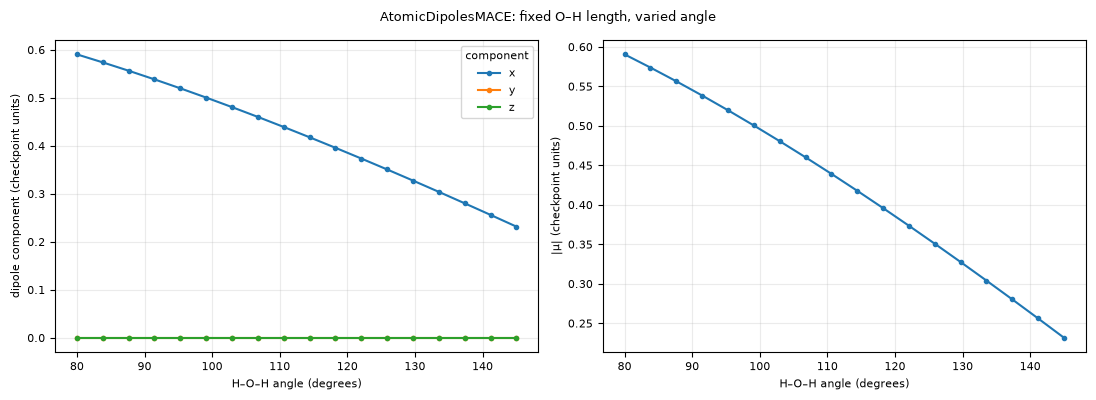

In [9]:
dipole_calc = MACECalculator(
    model_paths=str(require_model("dipole")),
    model_type="DipoleMACE",
    device=DEVICE, default_dtype=MODEL_DTYPE,
)
angle_grid = np.linspace(80.0, 145.0, 18)
dipoles = []
for angle in angle_grid:
    atoms = water_at_angle(angle)
    atoms.calc = dipole_calc
    dipoles.append(np.asarray(dipole_calc.get_property("dipole", atoms)))
dipoles = np.asarray(dipoles)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for component, label in enumerate(("x", "y", "z")):
    axes[0].plot(angle_grid, dipoles[:, component], marker="o", ms=3, label=label)
axes[0].set(xlabel="H–O–H angle (degrees)", ylabel="dipole component (checkpoint units)")
axes[0].legend(title="component")
axes[0].grid(alpha=0.25)
axes[1].plot(angle_grid, np.linalg.norm(dipoles, axis=1), marker="o", ms=3)
axes[1].set(xlabel="H–O–H angle (degrees)", ylabel="|μ| (checkpoint units)")
axes[1].grid(alpha=0.25)
fig.suptitle("AtomicDipolesMACE: fixed O–H length, varied angle")
plt.tight_layout()

In [10]:
angle_to_view = 104.5
atoms = water_at_angle(angle_to_view)
atoms.calc = dipole_calc
mu = np.asarray(dipole_calc.get_property("dipole", atoms))
display(show_structure(atoms, vectors=[(atoms.positions.mean(axis=0), mu, "predicted dipole", "#d97706", "e Å")],
               title=f"Predicted water dipole at {angle_to_view:.1f}°"))

<IPython.core.display.Javascript object>

#### Model-level rotation test

Rotate the geometry and compare μ(QR) with Qμ(R). The numerical error should be judged relative to model precision and prediction scale. For charged examples, rotate about the same defined origin and include the same charges.

In [11]:
angle = 104.5
atoms = water_at_angle(angle)
mu_original = np.asarray(dipole_calc.get_property("dipole", atoms))
Q = Rotation.from_euler("xyz", [37.0, 15.0, 68.0], degrees=True).as_matrix()
rotated = atoms.copy()
rotated.positions = atoms.positions @ Q.T
mu_rotated = np.asarray(dipole_calc.get_property("dipole", rotated))
print("equivariance residual (model units):", np.linalg.norm(mu_rotated - Q @ mu_original))

equivariance residual (model units): 7.473417450352271e-17


#### Diagnose a failure

If the residual is large, check that (a) the atom order was unchanged, (b) the vector was rotated using the same active/passive convention as the coordinates, (c) the charges and origin are consistent, (d) the chosen calculator/model type is correct, and (e) the training targets use one Cartesian convention. Plot μ components on a rotated series rather than comparing only |μ|.

## Continue

Compare this design in [T00 — Extending MACE](T00-Extending-MACE.ipynb). For training, see [Practice I](../MACE_in_practice_I/T01-MACE-Practice-I.ipynb) and [Practice II](../MACE_in_practice_II/T02-MACE-Practice-II.ipynb); for architecture, see [MACE Theory](../MACE_advanced/T03-MACE-Theory.ipynb). Source revisions, example-data limits and acknowledgements are in the [extension guide](README.md).